In [1]:
import pandas as pd
co2_df = pd.read_csv("/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/CO2_folder/co2_data_reformated.csv", parse_dates=['year_month'])
sea_level_df = pd.read_csv("/home/onyxia/work/Stat-App-Montee-des-oceans/my_data_folder/sea_level_folder/sea_level_monthly/sea_level_monthly.csv", parse_dates=['time'])
co2_df.head()

,year_month,value
0,2006-10-01,381.326667
1,2006-11-01,384.568000
2,2006-12-01,385.715000
3,2007-01-01,386.762500
4,2007-02-01,386.982500


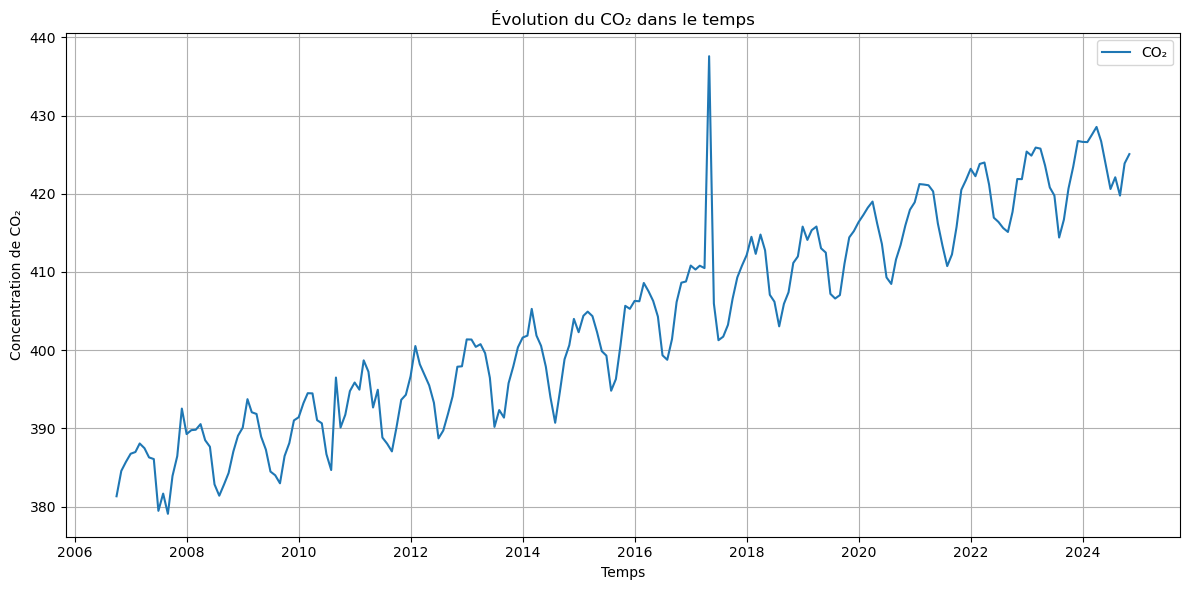

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(co2_df['year_month'], co2_df['value'], label='CO₂')
plt.xlabel('Temps')
plt.ylabel('Concentration de CO₂')
plt.title('Évolution du CO₂ dans le temps')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

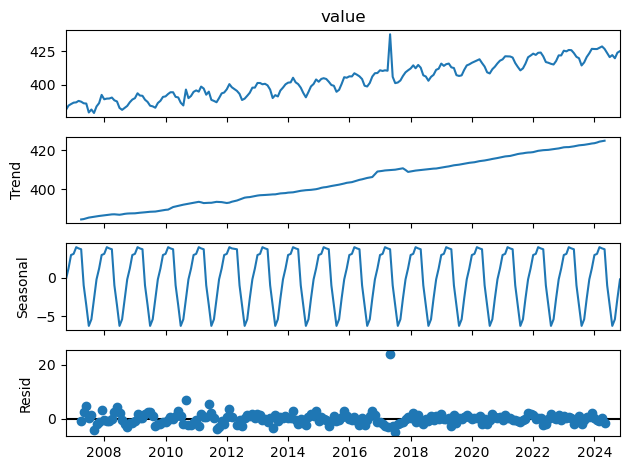

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
co2_df = co2_df.set_index('year_month')
decomposition = seasonal_decompose(co2_df['value'], model='additive', period=12)

decomposition.plot()
plt.tight_layout()
plt.show()

In [4]:
co2_trend = decomposition.trend
co2_trend_df = pd.DataFrame({
    'year_month': co2_trend.index,
    'co2_trend': co2_trend
})

co2_trend_df = co2_trend_df.drop(columns=['year_month'])
co2_trend_df = co2_trend_df.dropna()

In [5]:
co2_trend_df.head()

,co2_trend
year_month,
2007-04-01,384.565750
2007-05-01,384.752639
2007-06-01,385.115639
2007-07-01,385.504535
2007-08-01,385.725826


In [6]:
co2_trend_df.to_csv('co2_trend.csv', index=True)